# Crypto Price Forecasting

This notebook walks through the full price-modeling pipeline:

1. [Data Loading & Exploration](#1-data-loading--exploration)
2. [Train / Test Split](#2-train--test-split)
3. [Feature Engineering](#3-feature-engineering)
4. [Independent Forecasting](#4-independent-forecasting) — one model per coin
5. [Joint Forecasting](#5-joint-forecasting) — all coins in one model
6. [Model Comparison](#6-model-comparison)
7. [Predictions vs Actuals](#7-predictions-vs-actuals)

In [18]:
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src import data_loader, splitter, features, evaluate
from src.models.linear import all_linear_models, RidgeModel, LassoModel, ElasticNetModel
from src.models.kernel import all_kernel_models, KernelRidgeModel, SVRModel

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')

DATA_PATH   = 'data/crypto_data.csv'
CUTOFF      = '2023-01-01'   # everything before → train; on/after → test
N_LAGS      = 24             # hours of lag features
DEMO_COINS  = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'BNBUSDT']  # used in plots

---
## 1 · Data Loading & Exploration

In [19]:
df = data_loader.load(DATA_PATH)
print(f"Shape : {df.shape}")
print(f"Coins : {sorted(df['symbol'].unique())}")
print(f"Dates : {df['date'].min()}  →  {df['date'].max()}")
df.head(3)

Shape : (1120061, 52)
Coins : ['1INCHUSDT', 'AAVEUSDT', 'ADAUSDT', 'ALGOUSDT', 'ATOMUSDT', 'AVAXUSDT', 'BALUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'COMPUSDT', 'CRVUSDT', 'DENTUSDT', 'DOGEUSDT', 'DOTUSDT', 'DYDXUSDT', 'ETCUSDT', 'ETHUSDT', 'FILUSDT', 'HBARUSDT', 'ICPUSDT', 'LINKUSDT', 'LTCUSDT', 'MATICUSDT', 'MKRUSDT', 'RVNUSDT', 'SHIBUSDT', 'SOLUSDT', 'SUSHIUSDT', 'TRXUSDT', 'UNIUSDT', 'XMRUSDT']
Dates : 2017-08-17 04:00:00  →  2023-10-19 23:00:00


,date,symbol,open,high,low,close,volume usdt,tradecount,SMA_10,SMA_20,...,+DI,-DI,DX,ADX,Tenkan_sen,Kijun_sen,Senkou_Span_A,Senkou_Span_B,Chikou_Span,OBV
0,2020-12-25 05:00:00,1INCHUSDT,0.2000,3.0885,0.2000,2.5826,35530516.0,48768.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.8791,0.0
1,2020-12-25 06:00:00,1INCHUSDT,2.5824,2.6900,2.2249,2.5059,22440876.0,31099.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.7440,-22440876.0
2,2020-12-25 07:00:00,1INCHUSDT,2.5152,2.8870,2.3609,2.6237,21300426.0,33001.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.7513,-1140449.0


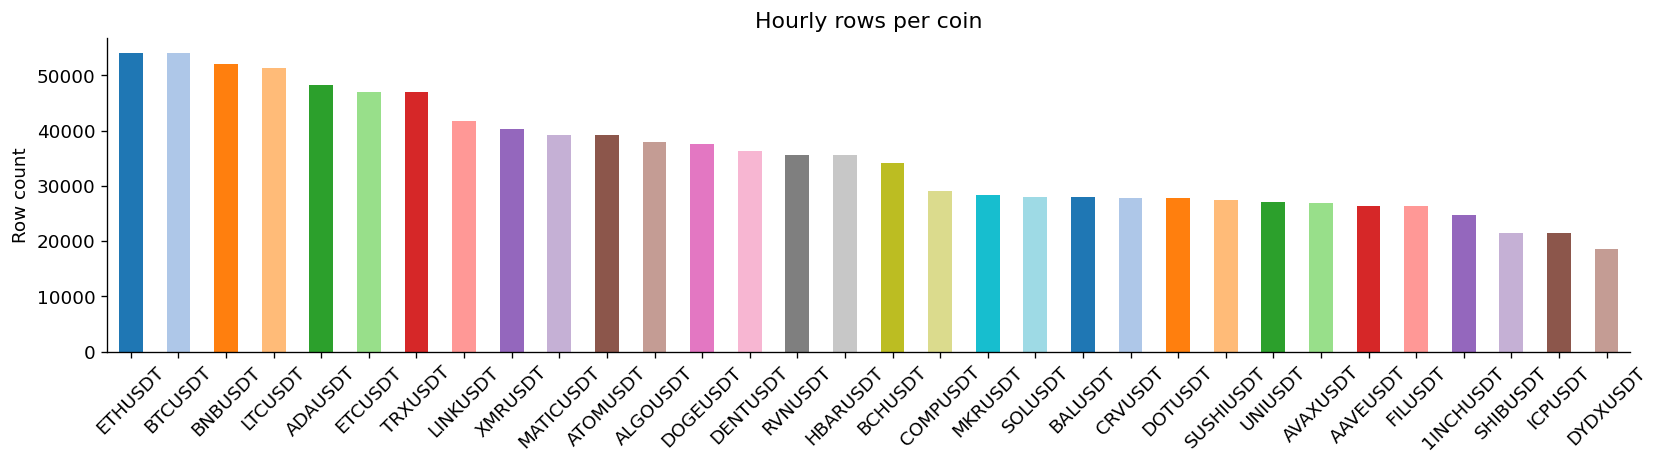

In [20]:
# Rows per coin
counts = df.groupby('symbol').size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
counts.plot(kind='bar', ax=ax, color=sns.color_palette('tab20', len(counts)))
ax.set_title('Hourly rows per coin')
ax.set_xlabel('')
ax.set_ylabel('Row count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

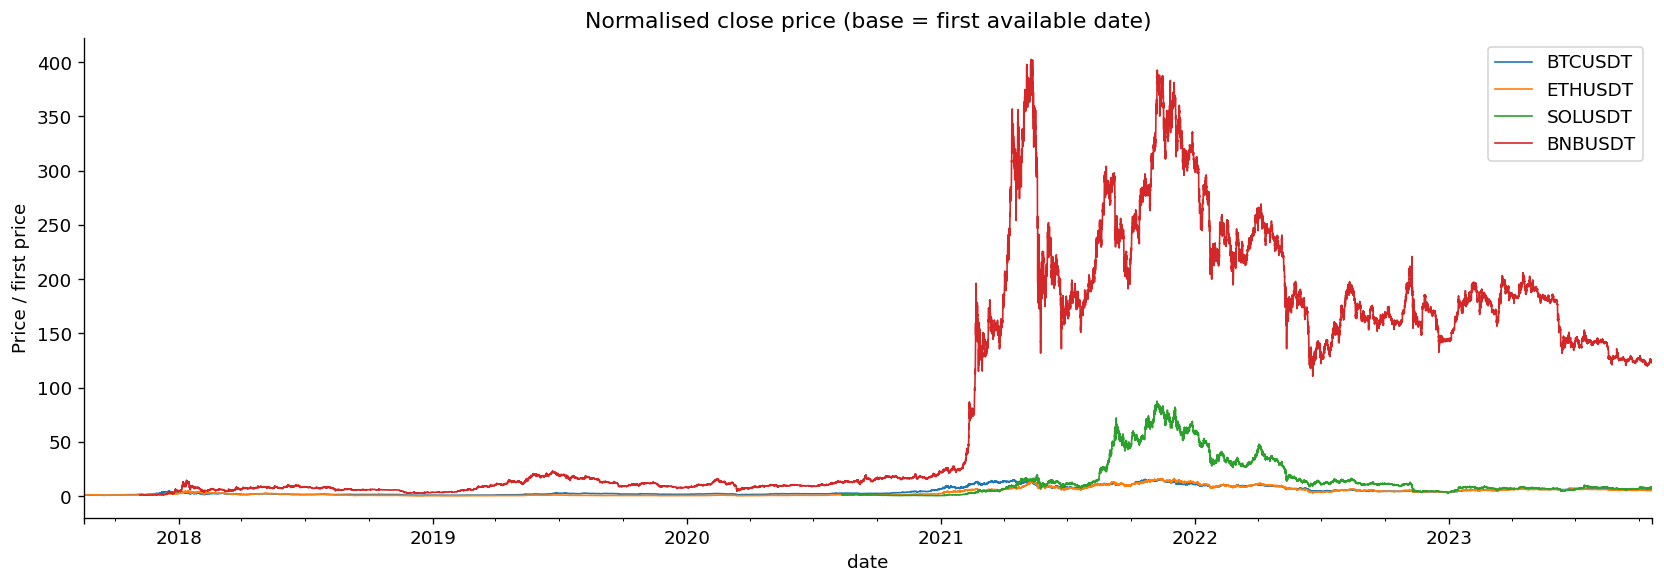

In [21]:
# Close-price history for demo coins (normalised to first value)
fig, ax = plt.subplots(figsize=(14, 5))
for coin in DEMO_COINS:
    sub = df[df['symbol'] == coin].set_index('date')['close'].dropna()
    (sub / sub.iloc[0]).plot(ax=ax, label=coin, linewidth=1)

ax.set_title('Normalised close price (base = first available date)')
ax.set_ylabel('Price / first price')
ax.legend()
plt.tight_layout()
plt.show()

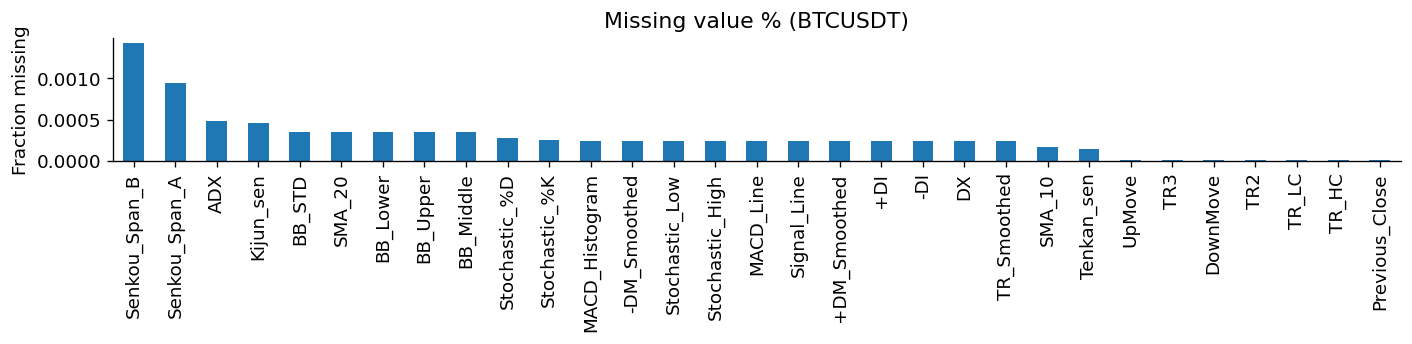

In [22]:
# Missing-value heatmap for a single coin
btc = df[df['symbol'] == 'BTCUSDT'].set_index('date')
missing_pct = btc.isnull().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct):
    fig, ax = plt.subplots(figsize=(12, 3))
    missing_pct.plot(kind='bar', ax=ax)
    ax.set_title('Missing value % (BTCUSDT)')
    ax.set_ylabel('Fraction missing')
    plt.tight_layout(); plt.show()
else:
    print('No missing values in BTCUSDT raw features.')

---
## 2 · Train / Test Split

We use a **hard datetime cutoff**: all rows before `CUTOFF` are training data; rows on or after are the held-out test set. This avoids any look-ahead leakage.

In [23]:
# Build features first so the split reflects the actual usable dataset
print('Building features (this takes ~30s on first run)...')
df_feat = features.build(df, n_lags=N_LAGS, joint=False)
print(f'Feature matrix shape: {df_feat.shape}')

Building features (this takes ~30s on first run)...
Feature matrix shape: (1117565, 105)


Train:  893,412 rows  [2017-08-20 09:00:00 → 2022-12-31 23:00:00]
Test :  224,153 rows  [2023-01-01 00:00:00 → 2023-10-19 22:00:00]


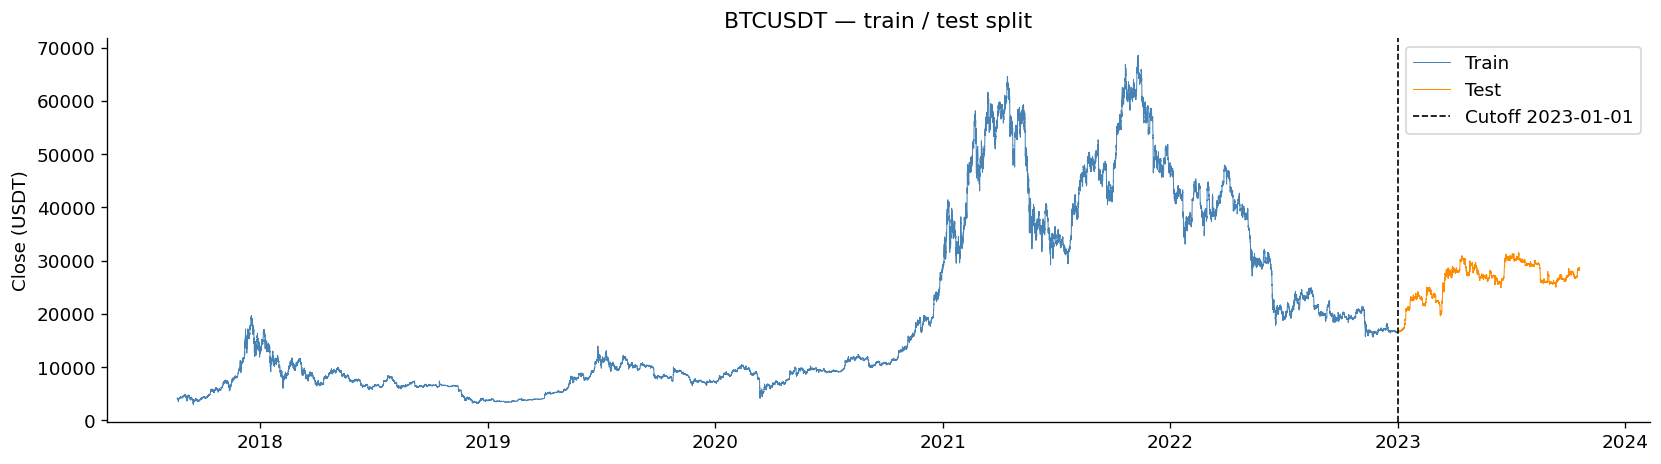

In [24]:
train_df, test_df = splitter.split(df_feat, cutoff=CUTOFF)
print(splitter.split_info(train_df, test_df))

# Visualise the split on BTC close price
btc_feat = df_feat[df_feat['symbol'] == 'BTCUSDT']
btc_tr   = btc_feat[btc_feat['date'] < CUTOFF]
btc_te   = btc_feat[btc_feat['date'] >= CUTOFF]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(btc_tr['date'], btc_tr['close'], color='steelblue',  linewidth=0.6, label='Train')
ax.plot(btc_te['date'], btc_te['close'], color='darkorange', linewidth=0.6, label='Test')
ax.axvline(pd.Timestamp(CUTOFF), color='black', linestyle='--', linewidth=1, label=f'Cutoff {CUTOFF}')
ax.set_title('BTCUSDT — train / test split')
ax.set_ylabel('Close (USDT)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3 · Feature Engineering

**Target**: `log_return_1h = log(close_{t+1} / close_t)` — next-hour log return.  
**Features** added on top of the raw technical indicators:
- `close_lagN` and `log_return_lagN` for N = 1 … 24
- Cyclical time encodings: `hour_sin/cos`, `dow_sin/cos`

In [25]:
feat_cols = features.get_feature_cols(df_feat, joint=False)
print(f'Total features: {len(feat_cols)}')
print('First 10:', feat_cols[:10])
print('Last  10:', feat_cols[-10:])

Total features: 85
First 10: ['open', 'high', 'low', 'close', 'volume usdt', 'tradecount', 'SMA_10', 'SMA_20', 'EMA_10', 'EMA_20']
Last  10: ['log_return_lag22', 'close_lag22', 'log_return_lag23', 'close_lag23', 'log_return_lag24', 'close_lag24', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


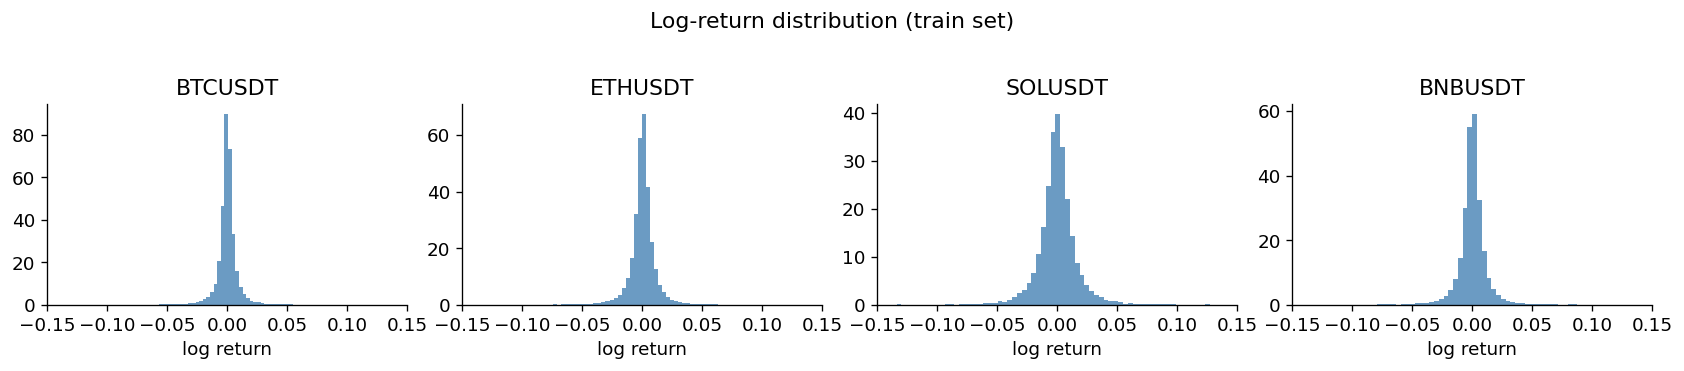

In [26]:
# Distribution of the target (log return) for demo coins
fig, axes = plt.subplots(1, len(DEMO_COINS), figsize=(14, 3), sharey=False)
for ax, coin in zip(axes, DEMO_COINS):
    vals = train_df[train_df['symbol'] == coin][features.TARGET].dropna()
    ax.hist(vals, bins=120, density=True, color='steelblue', alpha=0.8)
    ax.set_title(coin)
    ax.set_xlabel('log return')
    ax.set_xlim(-0.15, 0.15)
fig.suptitle('Log-return distribution (train set)', y=1.02)
plt.tight_layout()
plt.show()

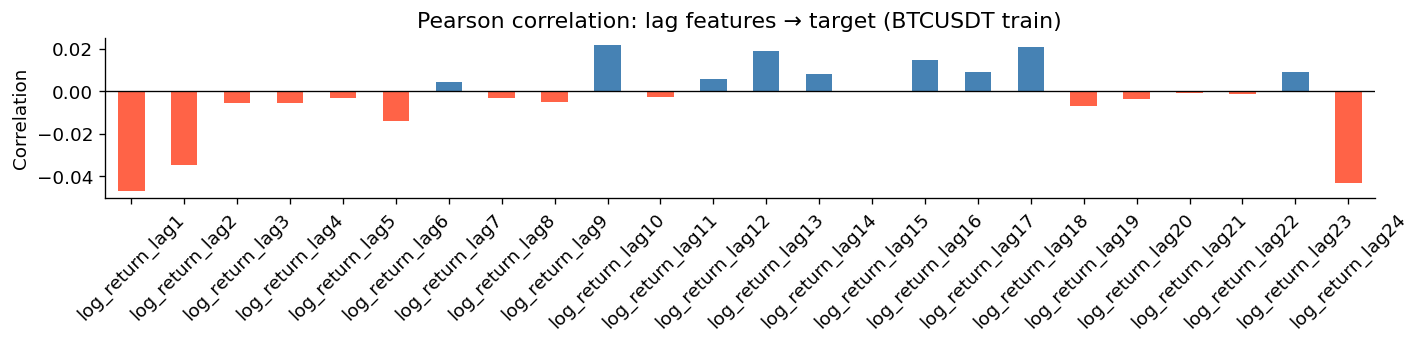

In [27]:
# Correlation of lag features with the target (BTC, train)
btc_tr_df = train_df[train_df['symbol'] == 'BTCUSDT']
lag_cols   = [c for c in feat_cols if 'log_return_lag' in c]
corr = btc_tr_df[lag_cols + [features.TARGET]].corr()[features.TARGET].drop(features.TARGET)

fig, ax = plt.subplots(figsize=(12, 3))
corr.plot(kind='bar', ax=ax, color=['steelblue' if v >= 0 else 'tomato' for v in corr])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Pearson correlation: lag features → target (BTCUSDT train)')
ax.set_xlabel('')
ax.set_ylabel('Correlation')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 4 · Independent Forecasting

Each coin gets its own scaler and its own trained model.  
We evaluate on `DEMO_COINS` with both linear and kernel methods.

In [28]:
def train_eval_coin(symbol, model, train_df, test_df):
    """Fit *model* on train rows for *symbol*, evaluate on test rows."""
    tr = train_df[train_df['symbol'] == symbol]
    te = test_df[test_df['symbol'] == symbol]
    X_tr, y_tr = features.make_Xy(tr)
    X_te, y_te = features.make_Xy(te)
    scaler = features.fit_scaler(X_tr)
    model.fit(scaler.transform(X_tr), y_tr)
    y_pred = model.predict(scaler.transform(X_te))
    return y_te, y_pred, te['date'].values


indep_models = [
    RidgeModel(alpha=1.0),
    LassoModel(alpha=1e-5),
    ElasticNetModel(alpha=1e-4, l1_ratio=0.5),
    KernelRidgeModel(alpha=1.0, kernel='rbf'),
    SVRModel(kernel='rbf', C=1.0, epsilon=0.01),
]

indep_results = []  # list of dicts

for coin in DEMO_COINS:
    for model in indep_models:
        print(f'  Training {model.name:<18} on {coin}...', end=' ', flush=True)
        y_te, y_pred, dates = train_eval_coin(coin, model, train_df, test_df)
        m = evaluate.evaluate(y_te, y_pred)
        m.update({'Symbol': coin, 'Model': model.name})
        indep_results.append(m)
        print(evaluate.format_metrics({k: v for k, v in m.items() if k not in ('Symbol','Model')}))

indep_df = pd.DataFrame(indep_results)[['Symbol','Model','MAE','RMSE','MAPE','DirAcc']]
print('\nDone.')

  Training Ridge              on BTCUSDT... MAE=0.002657  RMSE=0.004575  MAPE=4.119361  DirAcc=0.489653
  Training Lasso              on BTCUSDT... MAE=0.002633  RMSE=0.004568  MAPE=6.978843  DirAcc=0.502069
  Training ElasticNet         on BTCUSDT... MAE=0.002599  RMSE=0.004555  MAPE=4.243908  DirAcc=0.522049
  Training KernelRidge        on BTCUSDT... MAE=0.002759  RMSE=0.004633  MAPE=13.573660  DirAcc=0.495647
  Training SVR                on BTCUSDT... MAE=0.003394  RMSE=0.005056  MAPE=26.549702  DirAcc=0.477522
  Training Ridge              on ETHUSDT... MAE=0.002957  RMSE=0.004887  MAPE=42.424179  DirAcc=0.483516
  Training Lasso              on ETHUSDT... MAE=0.002904  RMSE=0.004865  MAPE=32.003329  DirAcc=0.483802
  Training ElasticNet         on ETHUSDT... MAE=0.002856  RMSE=0.004853  MAPE=30.170824  DirAcc=0.494220
  Training KernelRidge        on ETHUSDT... MAE=0.002969  RMSE=0.004910  MAPE=52.711776  DirAcc=0.474668
  Training SVR                on ETHUSDT... MAE=0.003546  

In [29]:
indep_df.sort_values(['Symbol', 'RMSE']).style \
    .background_gradient(subset=['MAE','RMSE'], cmap='RdYlGn_r') \
    .background_gradient(subset=['DirAcc'], cmap='RdYlGn') \
    .format({'MAE':'{:.5f}','RMSE':'{:.5f}','MAPE':'{:.4f}','DirAcc':'{:.4f}'})

,Symbol,Model,MAE,RMSE,MAPE,DirAcc
17,BNBUSDT,ElasticNet,0.00300,0.00490,2415.3853,0.4724
16,BNBUSDT,Lasso,0.00303,0.00491,3168.6196,0.4680
15,BNBUSDT,Ridge,0.00305,0.00491,3639.5281,0.4625
18,BNBUSDT,KernelRidge,0.00306,0.00495,3599.7431,0.4638
19,BNBUSDT,SVR,0.00335,0.00514,7696.5965,0.4567
2,BTCUSDT,ElasticNet,0.00260,0.00455,4.2439,0.5220
1,BTCUSDT,Lasso,0.00263,0.00457,6.9788,0.5021
0,BTCUSDT,Ridge,0.00266,0.00457,4.1194,0.4897
3,BTCUSDT,KernelRidge,0.00276,0.00463,13.5737,0.4956
4,BTCUSDT,SVR,0.00339,0.00506,26.5497,0.4775


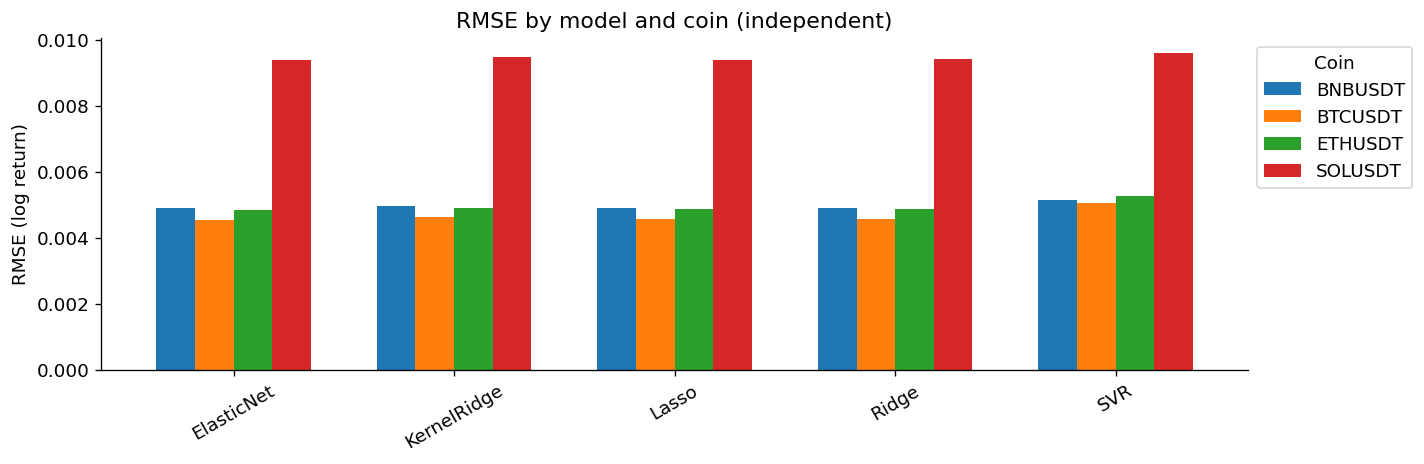

In [30]:
# Bar chart: RMSE per model per coin
pivot = indep_df.pivot(index='Model', columns='Symbol', values='RMSE')

fig, ax = plt.subplots(figsize=(12, 4))
pivot.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('RMSE by model and coin (independent)')
ax.set_ylabel('RMSE (log return)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Coin', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

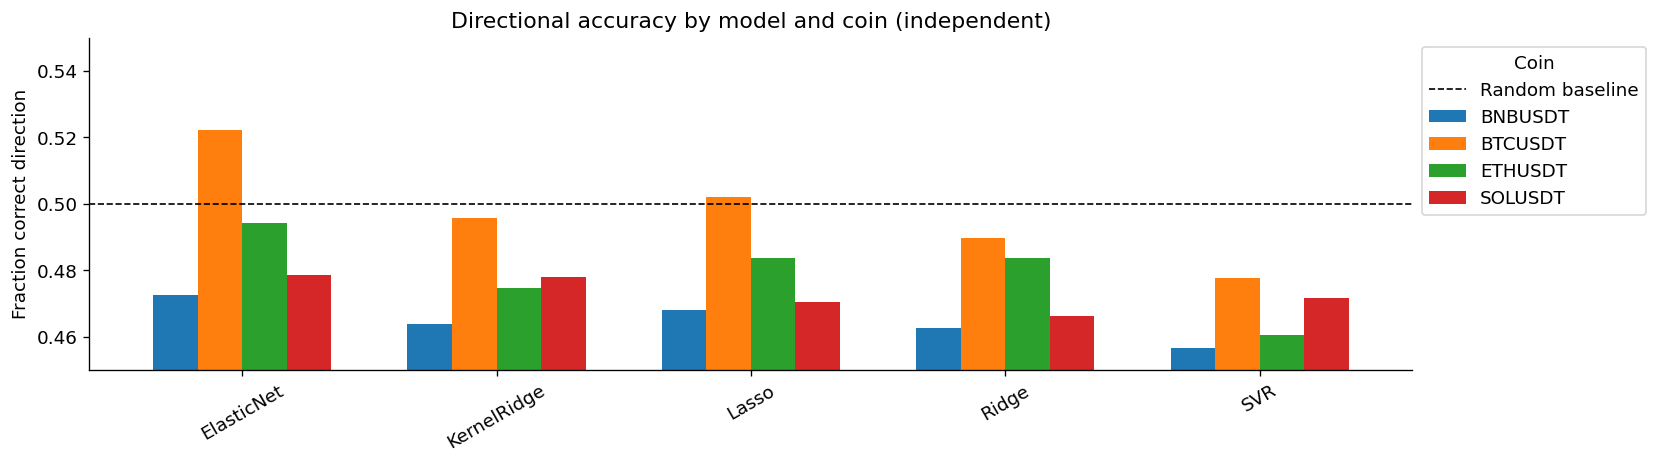

In [31]:
# Bar chart: Directional Accuracy
pivot_dir = indep_df.pivot(index='Model', columns='Symbol', values='DirAcc')

fig, ax = plt.subplots(figsize=(12, 4))
pivot_dir.plot(kind='bar', ax=ax, width=0.7)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Random baseline')
ax.set_title('Directional accuracy by model and coin (independent)')
ax.set_ylabel('Fraction correct direction')
ax.set_xlabel('')
ax.set_ylim(0.45, 0.55)
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Coin', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

---
## 5 · Joint Forecasting

All coins are stacked into a single design matrix. One-hot coin indicators are appended so the model can learn coin-specific offsets and cross-coin patterns.

In [32]:
print('Building joint features...')
# Limit to DEMO_COINS for speed; remove the filter for all 32 coins
df_joint = features.build(
    df[df['symbol'].isin(DEMO_COINS)],
    n_lags=N_LAGS,
    joint=True,
)
train_jdf, test_jdf = splitter.split(df_joint, cutoff=CUTOFF)
print(splitter.split_info(train_jdf, test_jdf))

X_tr_j, y_tr_j = features.make_Xy(train_jdf, joint=True)
X_te_j, y_te_j = features.make_Xy(test_jdf,  joint=True)

scaler_j = features.fit_scaler(X_tr_j)
X_tr_js  = scaler_j.transform(X_tr_j)
X_te_js  = scaler_j.transform(X_te_j)

print(f'Feature matrix: train {X_tr_js.shape}  test {X_te_js.shape}')

Building joint features...
Train:  159,860 rows  [2017-08-20 09:00:00 → 2022-12-31 23:00:00]
Test :   28,026 rows  [2023-01-01 00:00:00 → 2023-10-19 22:00:00]
Feature matrix: train (159860, 89)  test (28026, 89)


In [33]:
joint_models = [
    RidgeModel(alpha=1.0),
    LassoModel(alpha=1e-5),
    ElasticNetModel(alpha=1e-4, l1_ratio=0.5),
    KernelRidgeModel(alpha=1.0, kernel='rbf'),
    SVRModel(kernel='rbf', C=1.0, epsilon=0.01),
]

joint_results = []

for model in joint_models:
    print(f'  Training {model.name:<20}...', end=' ', flush=True)
    model.fit(X_tr_js, y_tr_j)

    # Global metrics
    y_pred_all = model.predict(X_te_js)
    m_global = evaluate.evaluate(y_te_j, y_pred_all)
    m_global.update({'Symbol': 'ALL', 'Model': model.name})
    joint_results.append(m_global)
    print(evaluate.format_metrics({k: v for k, v in m_global.items() if k not in ('Symbol','Model')}))

    # Per-coin breakdown
    for coin in DEMO_COINS:
        mask = test_jdf['symbol'] == coin
        X_c = scaler_j.transform(features.make_Xy(test_jdf[mask], joint=True)[0])
        y_c = features.make_Xy(test_jdf[mask], joint=True)[1]
        y_pred_c = model.predict(X_c)
        m_c = evaluate.evaluate(y_c, y_pred_c)
        m_c.update({'Symbol': coin, 'Model': model.name})
        joint_results.append(m_c)

joint_df = pd.DataFrame(joint_results)[['Symbol','Model','MAE','RMSE','MAPE','DirAcc']]
print('\nDone.')

  Training Ridge               ... MAE=0.003651  RMSE=0.006265  MAPE=1281.256613  DirAcc=0.475095
  Training Lasso               ... MAE=0.003633  RMSE=0.006258  MAPE=1126.386481  DirAcc=0.477949
  Training ElasticNet          ... MAE=0.003599  RMSE=0.006247  MAPE=758.607738  DirAcc=0.491437
  Training KernelRidge         ... MAE=0.003659  RMSE=0.006267  MAPE=1450.035491  DirAcc=0.489331
  Training SVR                 ... MAE=0.003890  RMSE=0.006368  MAPE=2594.715103  DirAcc=0.473346

Done.


In [34]:
joint_df.sort_values(['Symbol', 'RMSE']).style \
    .background_gradient(subset=['MAE','RMSE'], cmap='RdYlGn_r') \
    .background_gradient(subset=['DirAcc'], cmap='RdYlGn') \
    .format({'MAE':'{:.5f}','RMSE':'{:.5f}','MAPE':'{:.4f}','DirAcc':'{:.4f}'})

,Symbol,Model,MAE,RMSE,MAPE,DirAcc
10,ALL,ElasticNet,0.00360,0.00625,758.6077,0.4914
5,ALL,Lasso,0.00363,0.00626,1126.3865,0.4779
0,ALL,Ridge,0.00365,0.00627,1281.2566,0.4751
15,ALL,KernelRidge,0.00366,0.00627,1450.0355,0.4893
20,ALL,SVR,0.00389,0.00637,2594.7151,0.4733
14,BNBUSDT,ElasticNet,0.00299,0.00489,1660.5672,0.4691
9,BNBUSDT,Lasso,0.00302,0.00491,2666.5821,0.4570
4,BNBUSDT,Ridge,0.00304,0.00492,3080.9193,0.4544
19,BNBUSDT,KernelRidge,0.00303,0.00492,3112.7016,0.4690
24,BNBUSDT,SVR,0.00325,0.00504,6647.4032,0.4520


---
## 6 · Model Comparison

Side-by-side: independent (per-coin models) vs joint (shared model).

In [35]:
indep_agg = (
    indep_df.groupby('Model')[['RMSE','DirAcc']]
    .mean()
    .rename(columns={'RMSE':'RMSE_indep', 'DirAcc':'DirAcc_indep'})
)
joint_agg = (
    joint_df[joint_df['Symbol'] == 'ALL']
    .set_index('Model')[['RMSE','DirAcc']]
    .rename(columns={'RMSE':'RMSE_joint', 'DirAcc':'DirAcc_joint'})
)
compare = indep_agg.join(joint_agg, how='inner')
compare

,RMSE_indep,DirAcc_indep,RMSE_joint,DirAcc_joint
Model,,,,
ElasticNet,0.005922,0.491828,0.006247,0.491437
KernelRidge,0.005994,0.478020,0.006267,0.489331
Lasso,0.005936,0.481088,0.006258,0.477949
Ridge,0.005947,0.475451,0.006265,0.475095
SVR,0.006262,0.466603,0.006368,0.473346


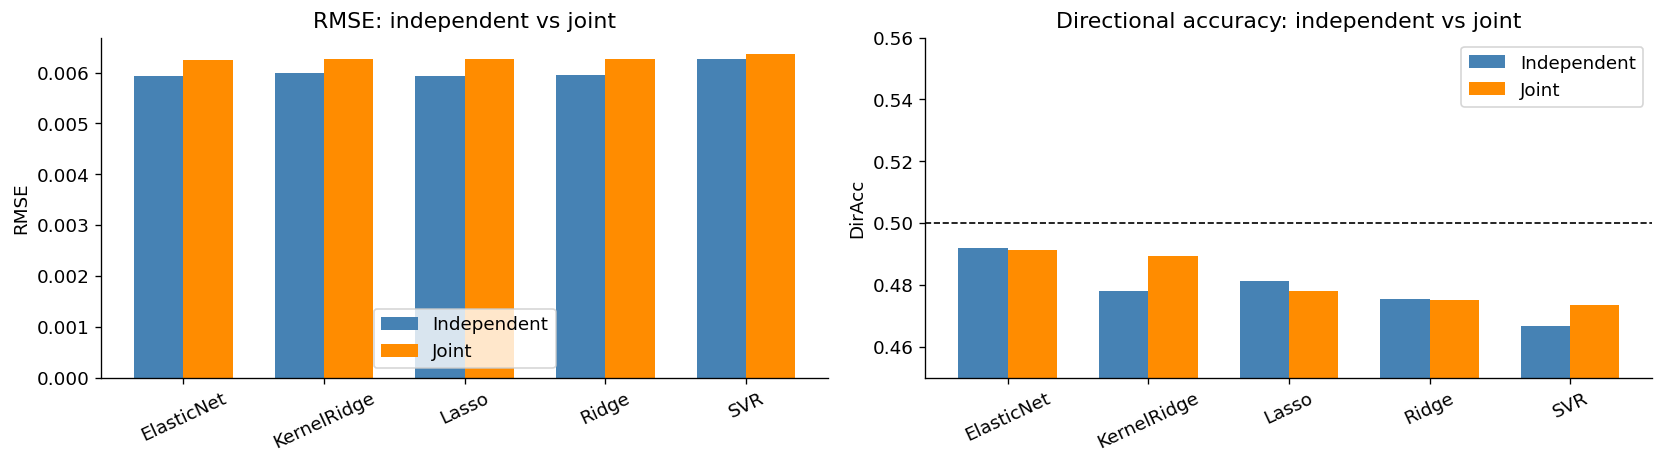

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

x = range(len(compare))
w = 0.35

ax1.bar([i - w/2 for i in x], compare['RMSE_indep'],  width=w, label='Independent', color='steelblue')
ax1.bar([i + w/2 for i in x], compare['RMSE_joint'],  width=w, label='Joint',       color='darkorange')
ax1.set_xticks(list(x)); ax1.set_xticklabels(compare.index, rotation=25)
ax1.set_title('RMSE: independent vs joint'); ax1.set_ylabel('RMSE'); ax1.legend()

ax2.bar([i - w/2 for i in x], compare['DirAcc_indep'], width=w, label='Independent', color='steelblue')
ax2.bar([i + w/2 for i in x], compare['DirAcc_joint'], width=w, label='Joint',       color='darkorange')
ax2.axhline(0.5, color='black', linestyle='--', linewidth=1)
ax2.set_xticks(list(x)); ax2.set_xticklabels(compare.index, rotation=25)
ax2.set_title('Directional accuracy: independent vs joint')
ax2.set_ylabel('DirAcc'); ax2.set_ylim(0.45, 0.56); ax2.legend()

plt.tight_layout()
plt.show()

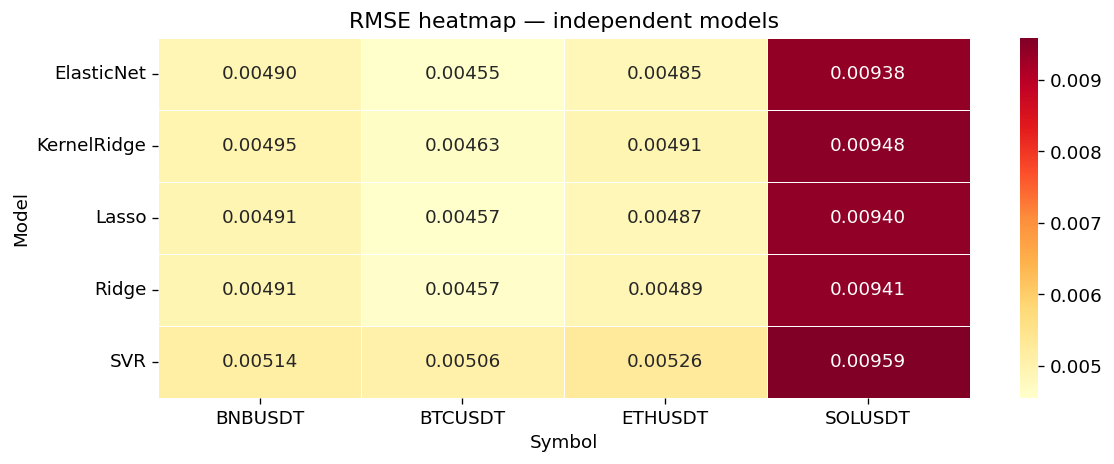

In [37]:
# Heatmap: RMSE across all (coin, model) pairs — independent mode
heat = indep_df.pivot(index='Model', columns='Symbol', values='RMSE')

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heat, annot=True, fmt='.5f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('RMSE heatmap — independent models')
plt.tight_layout()
plt.show()

---
## 7 · Predictions vs Actuals

Plot the model's predicted log-returns against the actual log-returns on the test set, and show the reconstructed close-price trajectory.

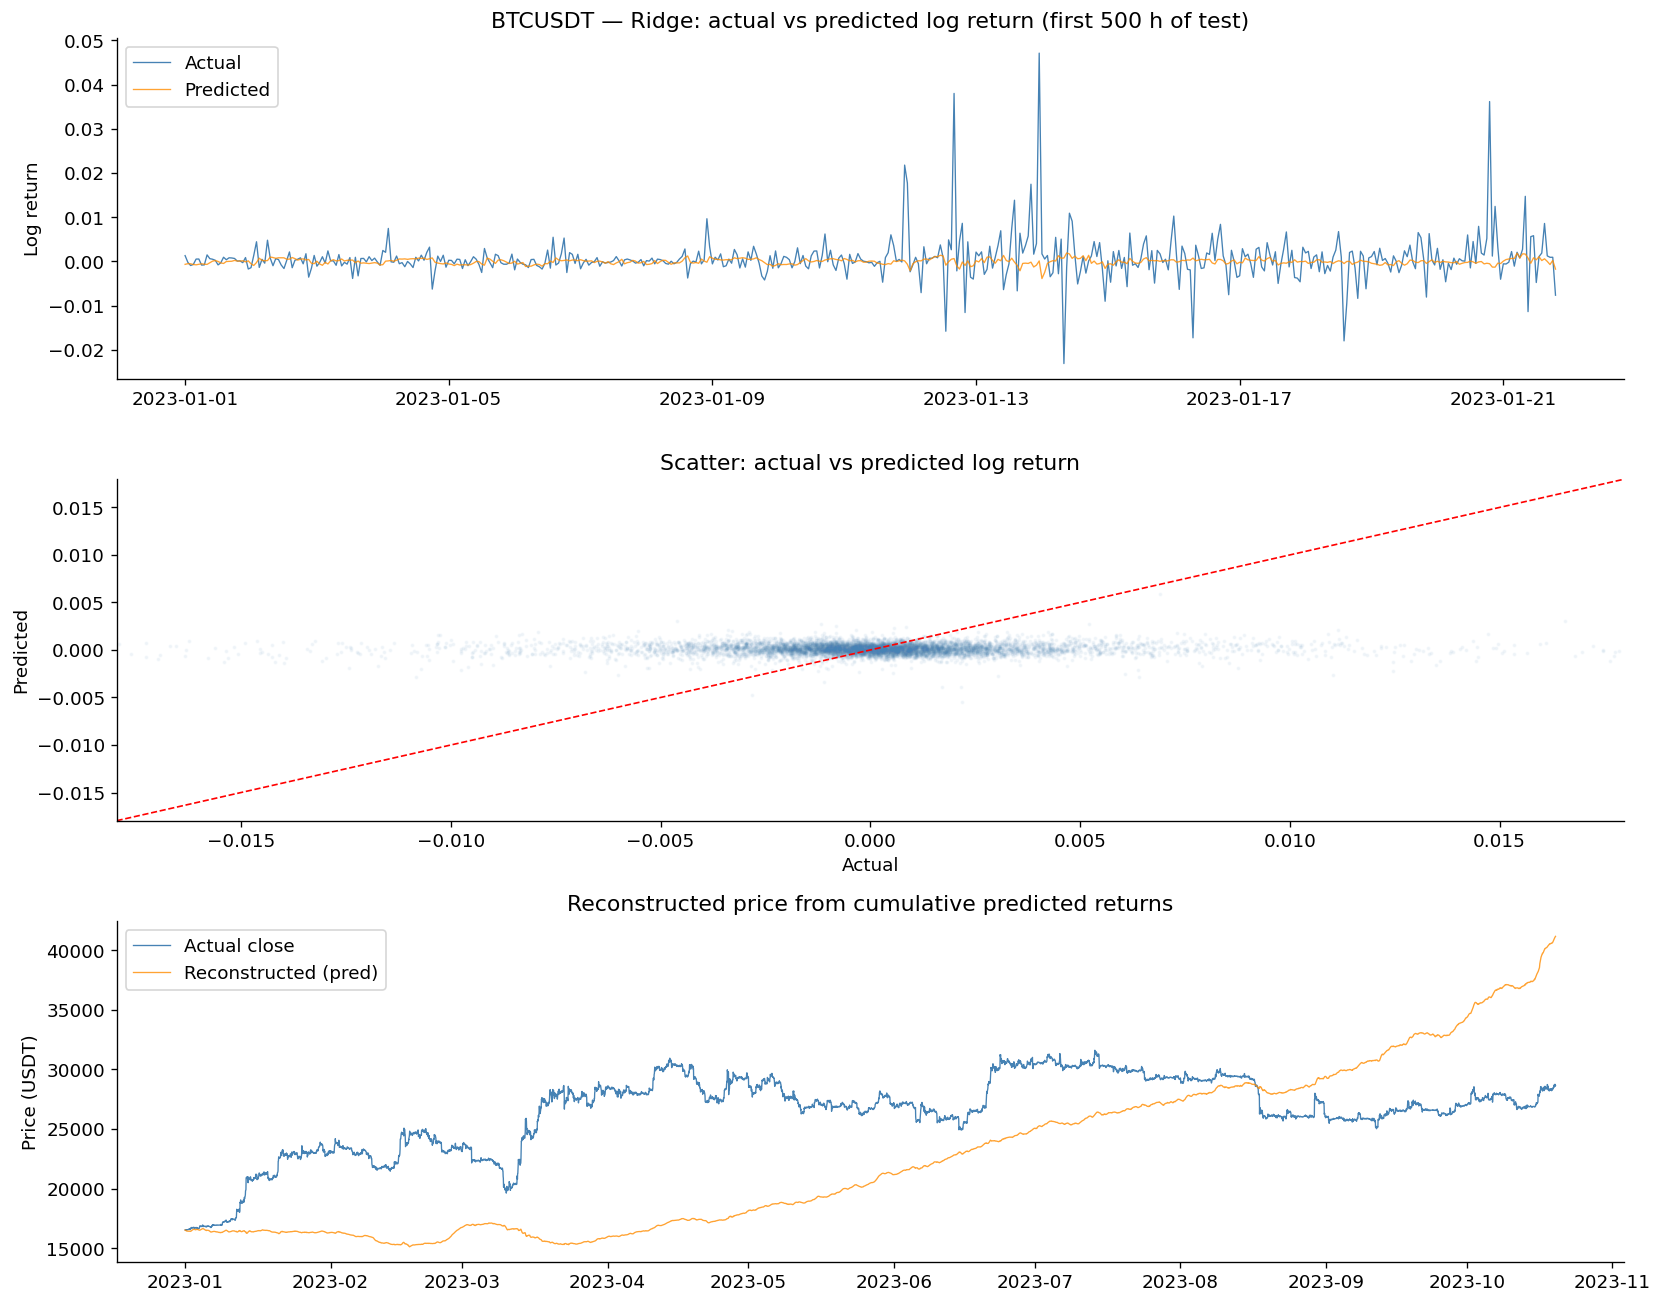

Test metrics: MAE=0.002657  RMSE=0.004575  MAPE=4.119361  DirAcc=0.489653


In [38]:
# Choose coin and model to inspect
INSPECT_COIN  = 'BTCUSDT'
INSPECT_MODEL = RidgeModel(alpha=1.0)

y_te_ins, y_pred_ins, dates_ins = train_eval_coin(
    INSPECT_COIN, INSPECT_MODEL, train_df, test_df
)
dates_ins = pd.to_datetime(dates_ins)

fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# — Actual vs Predicted log returns (first 500 hours for clarity)
n = 500
ax = axes[0]
ax.plot(dates_ins[:n], y_te_ins[:n],   label='Actual',    linewidth=0.8, color='steelblue')
ax.plot(dates_ins[:n], y_pred_ins[:n], label='Predicted', linewidth=0.8, color='darkorange', alpha=0.8)
ax.set_title(f'{INSPECT_COIN} — {INSPECT_MODEL.name}: actual vs predicted log return (first {n} h of test)')
ax.set_ylabel('Log return'); ax.legend()

# — Scatter: actual vs predicted
ax = axes[1]
lim = np.percentile(np.abs(y_te_ins), 99)
ax.scatter(y_te_ins, y_pred_ins, alpha=0.05, s=2, color='steelblue')
ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_title('Scatter: actual vs predicted log return'); ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')

# — Reconstructed close price (cumulative sum of log returns)
ax = axes[2]
close_actual = test_df[test_df['symbol'] == INSPECT_COIN]['close'].values
# Start reconstruction from the first test close price
start_price = close_actual[0]
recon_actual = start_price * np.exp(np.cumsum(y_te_ins))
recon_pred   = start_price * np.exp(np.cumsum(y_pred_ins))
ax.plot(dates_ins, close_actual[:len(dates_ins)], label='Actual close',       linewidth=0.8, color='steelblue')
ax.plot(dates_ins, recon_pred,                    label='Reconstructed (pred)', linewidth=0.8, color='darkorange', alpha=0.8)
ax.set_title('Reconstructed price from cumulative predicted returns')
ax.set_ylabel('Price (USDT)'); ax.legend()

plt.tight_layout()
plt.show()

m = evaluate.evaluate(y_te_ins, y_pred_ins)
print('Test metrics:', evaluate.format_metrics(m))

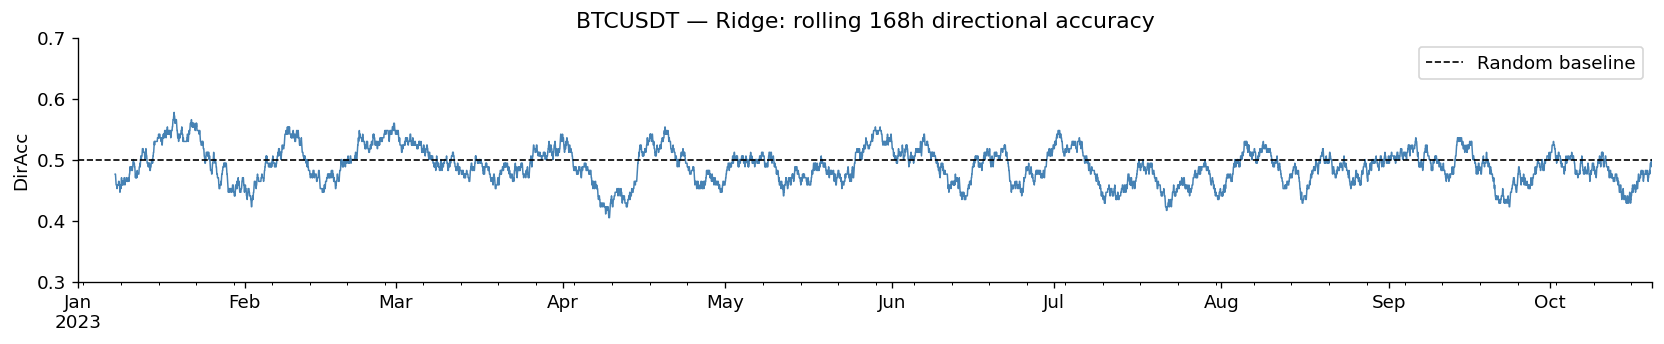

In [39]:
# Directional accuracy over a rolling window — shows whether signal is stable
WINDOW = 24 * 7  # 1 week

correct = (np.sign(y_te_ins) == np.sign(y_pred_ins)).astype(float)
rolling_acc = pd.Series(correct, index=dates_ins).rolling(WINDOW).mean()

fig, ax = plt.subplots(figsize=(14, 3))
rolling_acc.plot(ax=ax, color='steelblue', linewidth=0.9)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Random baseline')
ax.set_title(f'{INSPECT_COIN} — {INSPECT_MODEL.name}: rolling {WINDOW}h directional accuracy')
ax.set_ylabel('DirAcc'); ax.set_ylim(0.3, 0.7); ax.legend()
plt.tight_layout()
plt.show()